# Análisis de factores que predicen la empleabilidad de estudiantes universitarios

**Asignatura:** Data Experience

**Integrantes:** Leydy Yuliana Taborda Restrepo/Lizeth Nathalia Lozano Diaz

**Fecha:** 19/09/2026

---

## 1. Introducción y objetivo

Este trabajo analiza un conjunto de datos de 50.000 estudiantes universitarios del área de tecnología, con el fin de identificar qué factores académicos y de habilidades se asocian con la empleabilidad y con las condiciones de su primer empleo.

**Pregunta principal:** ¿Qué factores académicos y de habilidades predicen mejor si un estudiante universitario logrará empleabilidad?

**Preguntas de apoyo:**
1. ¿Qué variable académica tiene mayor asociación con la empleabilidad?
2. ¿Qué habilidades blandas diferencian más a los contratados de los que no?
3. ¿La empleabilidad y el salario varían según el género y la carrera?
4. ¿Qué tan grande es la diferencia del salario inicial entre estudiantes con y sin experiencia previa?
5. ¿Qué combinación de variables predice mejor en qué tipo de compañía quedan contratados?

## 2. Descripción del conjunto de datos

El conjunto de datos contiene **50.000 registros** y **29 variables**. Las variables se dividen en dos momentos:

- **Variables previas (causas posibles):** describen el perfil del estudiante antes de buscar empleo. Son las que se usan para predecir.
- **Variables de resultado:** solo existen después de saber si fue contratado. No se usan como predictoras.

| Grupo | Variable | Descripción |
|---|---|---|
| Identificación | Student_ID | Identificador único |
| | Age | Edad |
| | Gender | Género |
| Académicas | University_Year | Año que cursa (Freshman → Senior) |
| | Major | Carrera |
| | CGPA | Promedio acumulado (0 a 4) |
| | Academic_Performance | Rendimiento (Poor / Average / Good / Excellent) |
| | Attendance_Percentage | Porcentaje de asistencia |
| | Study_Hours_Per_Week | Horas de estudio por semana |
| | Certifications | Número de certificaciones |
| Habilidades | Programming_Skill | Nivel de programación (1 a 10) |
| | Problem_Solving | Resolución de problemas (1 a 10) |
| | Communication_Skills | Comunicación (1 a 10) |
| | Teamwork | Trabajo en equipo (1 a 10) |
| | English_Proficiency | Nivel de inglés (Basic / Intermediate / Advanced) |
| Perfil / experiencia | Projects_Completed | Proyectos completados |
| | Hackathons | Hackatones en que participó |
| | Internships | Número de prácticas realizadas |
| | Leadership_Experience | Experiencia de liderazgo (Yes / No) |
| | GitHub_Profile | Tiene perfil en GitHub (Yes / No) |
| | LinkedIn_Profile | Tiene perfil en LinkedIn (Yes / No) |
| | Resume_Score | Puntaje de la hoja de vida |
| | Interview_Score | Puntaje en la entrevista |
| **Resultado** | Employability_Score | Puntaje compuesto de empleabilidad |
| | Placement_Status | Si fue contratado o no |
| | Company_Tier | Nivel de empresa (Tier 1 / 2 / 3) |
| | Career_Field | Cargo o área en que quedó |
| | Placement_Mode | Vía de contratación |
| | Starting_Salary_USD | Salario inicial (USD) |

## 3. Metodología

1. Carga y revisión inicial del conjunto de datos.
2. Limpieza: duplicados, valores vacíos y tratamiento de salarios en cero.
3. Análisis descriptivo: tendencia central, dispersión y valores atípicos.
4. Exploración de correlaciones (ejemplo didáctico + datos reales).
5. Respuesta a cada pregunta de apoyo con código, gráfica y conclusión.
6. Modelo predictivo para responder la pregunta principal.


## 4. Librerías

Importamos todas las librerías que se usan en el cuaderno.

In [1]:
# pandas: manejo y análisis de datos en tabla (DataFrame)
# numpy: operaciones numéricas y selección de tipos de columnas
# matplotlib: generación de gráficas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Tamaño por defecto de las gráficas
plt.rcParams["figure.figsize"] = (8, 5)

## 5. Carga de datos

Cargamos el archivo CSV. El separador de columnas es punto y coma (`;`). Revisamos dimensiones, primeras filas, tipos de datos, valores vacíos y duplicados.

In [2]:
# Ruta del archivo. Cambiar si está en otra ubicación.
# URL del archivo en GitHub. No se necesita descargar nada: pandas lo lee directamente.
URL = "https://raw.githubusercontent.com/Leydyuli21/DataXEAN/main/student_career_success_dataset.csv"

# Leemos el archivo directamente desde GitHub. El separador de columnas es punto y coma.
df = pd.read_csv(URL, sep=";")

# Dimensiones: cuántas filas y columnas tiene el dataset.
print("Filas y columnas:", df.shape)

# Primeras 5 filas para ver la estructura del dataset.
print("\nPrimeras filas:")
print(df.head())

# Información general: tipos de datos y cuántos valores tiene cada columna.
print("\nInformación del dataset:")
print(df.info())

# Cuántos valores vacíos hay por columna.
print("\nValores vacíos por columna:")
print(df.isnull().sum())

# Cuántas filas duplicadas existen.
print("\nDuplicados:", df.duplicated().sum())

Filas y columnas: (50000, 29)

Primeras filas:
  Student_ID  Age  Gender University_Year                   Major  \
0   ST000001   22    Male       Sophomore        Computer Science   
1   ST000002   20  Female        Freshman        Computer Science   
2   ST000003   23    Male          Senior  Information Technology   
3   ST000004   23  Female          Senior  Information Technology   
4   ST000005   23  Female          Senior    Software Engineering   

   Attendance_Percentage  Study_Hours_Per_Week  CGPA Academic_Performance  \
0                     86                    21  3.28                 Good   
1                     64                    18  2.53                 Poor   
2                     75                    19  2.83              Average   
3                     80                    19  2.80              Average   
4                     73                    19  2.93              Average   

   Programming_Skill  ...  Teamwork  Problem_Solving  English_Proficiency  

In [3]:
# Conteo de valores no vacíos por columna (complementa el paso anterior).
# Sirve para confirmar cuáles columnas tienen datos completos.
df.count()

Student_ID               50000
Age                      50000
Gender                   50000
University_Year          50000
Major                    50000
Attendance_Percentage    50000
Study_Hours_Per_Week     50000
CGPA                     50000
Academic_Performance     50000
Programming_Skill        50000
Projects_Completed       50000
Certifications           50000
Hackathons               50000
GitHub_Profile           50000
Internships              50000
Leadership_Experience    50000
LinkedIn_Profile         50000
Resume_Score             50000
Communication_Skills     50000
Teamwork                 50000
Problem_Solving          50000
English_Proficiency      50000
Interview_Score          50000
Employability_Score      49999
Placement_Status         50000
Company_Tier             50000
Career_Field             50000
Placement_Mode           50000
Starting_Salary_USD      50000
dtype: int64

## 6. Limpieza de datos

Eliminamos duplicados y filas con valores vacíos. Antes de borrar cualquier dato, verificamos qué se va a eliminar y por qué.

In [4]:
# Eliminamos filas duplicadas (registros exactamente iguales en todas las columnas).
# Eliminamos filas con algún valor vacío (NaN).
# reset_index(drop=True) reinicia la numeración de filas.
df = df.drop_duplicates()
df = df.dropna()
df = df.reset_index(drop=True)

print("Filas después de limpiar:", len(df))

Filas después de limpiar: 49999


In [5]:
# Verificamos cuántos valores quedan en cada columna después de la limpieza.
# El resultado debe ser el mismo número para todas: 49.999.
df.count()

Student_ID               49999
Age                      49999
Gender                   49999
University_Year          49999
Major                    49999
Attendance_Percentage    49999
Study_Hours_Per_Week     49999
CGPA                     49999
Academic_Performance     49999
Programming_Skill        49999
Projects_Completed       49999
Certifications           49999
Hackathons               49999
GitHub_Profile           49999
Internships              49999
Leadership_Experience    49999
LinkedIn_Profile         49999
Resume_Score             49999
Communication_Skills     49999
Teamwork                 49999
Problem_Solving          49999
English_Proficiency      49999
Interview_Score          49999
Employability_Score      49999
Placement_Status         49999
Company_Tier             49999
Career_Field             49999
Placement_Mode           49999
Starting_Salary_USD      49999
dtype: int64

**Resultado de la limpieza:**
- `drop_duplicates()` → no borró nada (había **0 duplicados**).
- `dropna()` → eliminó **1 sola fila** (la que tenía `Employability_Score` vacío).
- La limpieza fue segura: no se perdió información relevante.

In [6]:
# Verificamos el significado de los salarios en 0.
# Un salario de 0 podría parecer un error, pero hay que comprobarlo.
# Cruzamos con la columna de estado de contratación para entenderlo.
print("¿Qué significa salario = 0?")
print(pd.crosstab(df["Starting_Salary_USD"] == 0, df["Placement_Status"]))

# Conclusión: los salarios en 0 corresponden EXACTAMENTE a los no contratados.
# No son un error. No se eliminan (son registros válidos).
# Pero SÍ los filtramos cuando calculemos promedios de salario, para no distorsionarlos.
df_pagados = df[df["Starting_Salary_USD"] > 0].copy()
print("\nContratados con salario registrado:", len(df_pagados))

¿Qué significa salario = 0?
Placement_Status     Not Placed  Placed
Starting_Salary_USD                    
False                         0   39039
True                      10960       0

Contratados con salario registrado: 39039


## 7. Análisis descriptivo

Antes de responder las preguntas, caracterizamos el comportamiento general de las variables numéricas mediante medidas de tendencia central y de dispersión.

In [7]:
# Variables numéricas que vamos a analizar en el análisis descriptivo.
variables = [
    "Attendance_Percentage", "Study_Hours_Per_Week", "CGPA",
    "Programming_Skill", "Projects_Completed", "Certifications",
    "Hackathons", "Internships", "Resume_Score",
    "Communication_Skills", "Teamwork", "Problem_Solving",
    "Interview_Score", "Employability_Score"
]

# --- Medidas de tendencia central ---
# Media: el promedio de todos los valores.
# Mediana: el valor que queda en el centro cuando se ordenan los datos.
# Moda: el valor que aparece con más frecuencia.
media   = df[variables].mean()
mediana = df[variables].median()
moda    = df[variables].mode().iloc[0]

tendencia_central = pd.DataFrame({
    "Media": media,
    "Mediana": mediana,
    "Moda": moda
})

print("=== Medidas de tendencia central ===")
print(tendencia_central.round(2))

=== Medidas de tendencia central ===
                        Media  Mediana    Moda
Attendance_Percentage   81.41    82.00   83.00
Study_Hours_Per_Week    21.53    21.00   21.00
CGPA                     3.11     3.11    3.15
Programming_Skill        7.14     7.00    7.00
Projects_Completed       8.62     9.00    9.00
Certifications           1.72     2.00    2.00
Hackathons               3.09     3.00    3.00
Internships              4.05     4.00    5.00
Resume_Score            96.05   100.00  100.00
Communication_Skills     8.44     9.00   10.00
Teamwork                 7.01     7.00    7.00
Problem_Solving          7.18     7.00    7.00
Interview_Score         77.52    78.00   79.00
Employability_Score    213.99   217.25  230.50


In [8]:
# --- Medidas de dispersión ---
# Mínimo y máximo: los valores extremos.
# Rango: la distancia entre el mínimo y el máximo.
# Varianza: qué tan separados están los datos de la media (en escala cuadrática).
# Desviación estándar: igual que la varianza pero en la misma escala de los datos.
minimo   = df[variables].min()
maximo   = df[variables].max()
rango    = maximo - minimo
varianza = df[variables].var()
desv_est = df[variables].std()

dispersion = pd.DataFrame({
    "Mínimo": minimo,
    "Máximo": maximo,
    "Rango": rango,
    "Varianza": varianza,
    "Desv. Estándar": desv_est
})

print("=== Medidas de dispersión ===")
print(dispersion.round(2))

=== Medidas de dispersión ===
                       Mínimo  Máximo   Rango  Varianza  Desv. Estándar
Attendance_Percentage    50.0  100.00   50.00     94.28            9.71
Study_Hours_Per_Week      5.0   45.00   40.00     48.65            6.97
CGPA                      2.0    4.00    2.00      0.08            0.29
Programming_Skill         1.0   10.00    9.00      2.27            1.51
Projects_Completed        0.0   15.00   15.00      6.28            2.51
Certifications            0.0    8.00    8.00      1.87            1.37
Hackathons                0.0   10.00   10.00      2.76            1.66
Internships               0.0    5.00    5.00      1.01            1.01
Resume_Score             44.0  100.00   56.00     53.75            7.33
Communication_Skills      3.0   10.00    7.00      1.93            1.39
Teamwork                  2.0   10.00    8.00      2.58            1.61
Problem_Solving           1.0   10.00    9.00      2.80            1.67
Interview_Score          17.0  100

In [9]:
# --- Análisis específico del puntaje de empleabilidad ---
empleabilidad = df["Employability_Score"]

print("=== Análisis del Employability Score ===")
print(f"Media:              {empleabilidad.mean():.2f}")
print(f"Mediana:            {empleabilidad.median():.2f}")
print(f"Moda:               {empleabilidad.mode().iloc[0]:.2f}")
print(f"Mínimo:             {empleabilidad.min():.2f}")
print(f"Máximo:             {empleabilidad.max():.2f}")
print(f"Rango:              {(empleabilidad.max() - empleabilidad.min()):.2f}")
print(f"Varianza:           {empleabilidad.var():.2f}")
print(f"Desviación estándar:{empleabilidad.std():.2f}")

# Interpretación automática de la relación entre media y mediana.
if empleabilidad.mean() > empleabilidad.median():
    print("\nLa media es superior a la mediana: puede haber algunos valores altos que jalen el promedio hacia arriba.")
elif empleabilidad.mean() < empleabilidad.median():
    print("\nLa media es inferior a la mediana: puede haber algunos valores bajos que jalen el promedio hacia abajo.")
else:
    print("\nMedia y mediana son iguales: distribución equilibrada.")

=== Análisis del Employability Score ===
Media:              213.99
Mediana:            217.25
Moda:               230.50
Mínimo:             82.30
Máximo:             279.05
Rango:              196.75
Varianza:           719.55
Desviación estándar:26.82

La media es inferior a la mediana: puede haber algunos valores bajos que jalen el promedio hacia abajo.


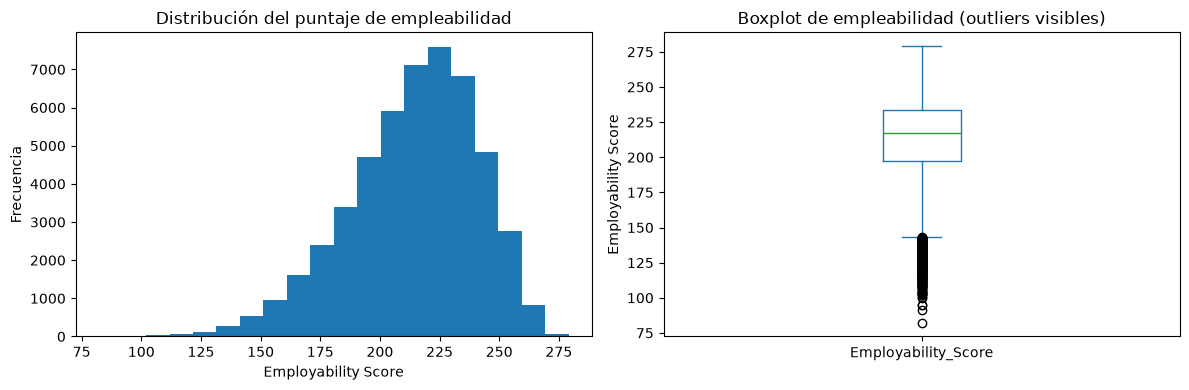

In [10]:
# --- Distribución del puntaje de empleabilidad: histograma y boxplot ---
# El histograma muestra cómo se distribuyen los valores.
# El boxplot muestra la mediana, los cuartiles y los valores atípicos.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Employability_Score"].plot.hist(bins=20, ax=axes[0])
axes[0].set_title("Distribución del puntaje de empleabilidad")
axes[0].set_xlabel("Employability Score")
axes[0].set_ylabel("Frecuencia")

df["Employability_Score"].plot.box(ax=axes[1])
axes[1].set_title("Boxplot de empleabilidad (outliers visibles)")
axes[1].set_ylabel("Employability Score")

plt.tight_layout()
plt.show()

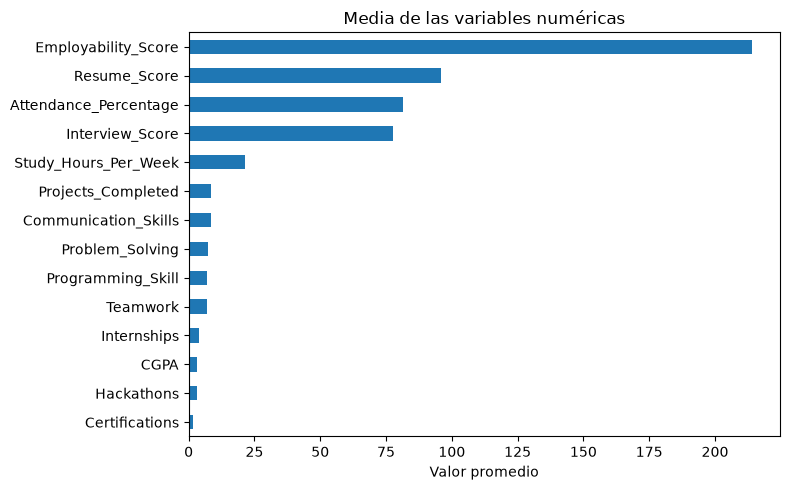

In [11]:
# --- Gráfica de la media de cada variable ---
# Permite comparar en un vistazo el nivel promedio de cada variable.
media.sort_values().plot.barh()
plt.title("Media de las variables numéricas")
plt.xlabel("Valor promedio")
plt.tight_layout()
plt.show()

## 8. Detección de valores atípicos (outliers)

Usamos el **método IQR**: un valor se considera atípico si está por fuera del rango `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`, donde Q1 y Q3 son el primer y tercer cuartil.

In [12]:
# Calculamos los cuartiles y el rango intercuartílico (IQR).
Q1  = df[variables].quantile(0.25)
Q3  = df[variables].quantile(0.75)
IQR = Q3 - Q1

# Límites: valores fuera de estos se consideran atípicos.
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

# Contamos cuántos valores atípicos hay en cada variable.
outliers = ((df[variables] < limite_inf) | (df[variables] > limite_sup)).sum()

# Porcentaje de outliers respecto al total de filas.
pct_outliers = (outliers / len(df) * 100).round(2)

resumen_outliers = pd.DataFrame({
    "Cantidad": outliers,
    "Porcentaje (%)": pct_outliers
})

print("=== Valores atípicos por variable ===")
print(resumen_outliers.sort_values("Cantidad", ascending=False))

# Variable con más outliers.
var_mas = outliers.idxmax()
print(f"\nLa variable con más outliers es '{var_mas}' con {outliers.max()} casos "
      f"({pct_outliers[var_mas]:.2f}% del total).")

=== Valores atípicos por variable ===
                       Cantidad  Porcentaje (%)
Resume_Score               6354           12.71
Projects_Completed          806            1.61
Employability_Score         545            1.09
Interview_Score             490            0.98
CGPA                        267            0.53
Attendance_Percentage       249            0.50
Study_Hours_Per_Week        244            0.49
Problem_Solving             192            0.38
Hackathons                  191            0.38
Programming_Skill            88            0.18
Certifications               29            0.06
Teamwork                     24            0.05
Communication_Skills          0            0.00
Internships                   0            0.00

La variable con más outliers es 'Resume_Score' con 6354 casos (12.71% del total).


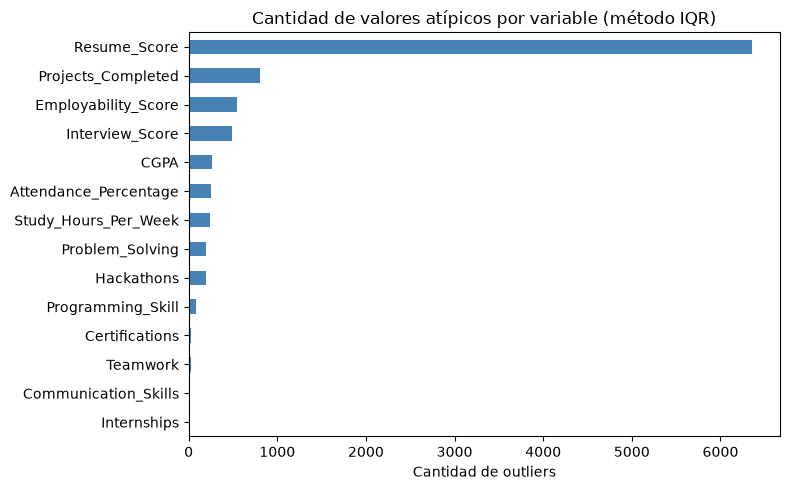

In [13]:
# --- Gráfica de cantidad de outliers por variable ---
outliers.sort_values().plot.barh(color="steelblue")
plt.title("Cantidad de valores atípicos por variable (método IQR)")
plt.xlabel("Cantidad de outliers")
plt.tight_layout()
plt.show()

In [14]:
# --- Posibles hipótesis basadas en el análisis descriptivo y de outliers ---

# Variable con mayor relación positiva con la empleabilidad (se calcula aquí para la hipótesis).
corr_desc = (df[variables].corr()["Employability_Score"]
                          .drop("Employability_Score")
                          .sort_values(ascending=False))

variable_mayor_relacion = corr_desc.index[0]
variable_menor_relacion = corr_desc.index[-1]
variable_mas_outliers   = outliers.idxmax()

print("=== Posibles hipótesis ===")
print(f"H1: Un mayor nivel de '{variable_mayor_relacion}' podría estar relacionado "
      f"con un mayor nivel de empleabilidad (r = {corr_desc.iloc[0]:.3f}).")
print("H2: Los estudiantes con mejores resultados académicos y mayores habilidades "
      "profesionales podrían presentar mayores niveles de empleabilidad.")
print(f"H3: Los valores atípicos en '{variable_mas_outliers}' podrían influir en "
      "los promedios y en la interpretación de los resultados.")

print("\n=== Conclusión del análisis descriptivo ===")
print(f"La variable con mayor relación con la empleabilidad es '{variable_mayor_relacion}' "
      f"(r = {corr_desc.iloc[0]:.3f}).")
print(f"La de menor relación es '{variable_menor_relacion}' "
      f"(r = {corr_desc.iloc[-1]:.3f}).")
print(f"La que presenta más outliers es '{variable_mas_outliers}' "
      f"({outliers.max()} casos).")

=== Posibles hipótesis ===
H1: Un mayor nivel de 'Interview_Score' podría estar relacionado con un mayor nivel de empleabilidad (r = 0.845).
H2: Los estudiantes con mejores resultados académicos y mayores habilidades profesionales podrían presentar mayores niveles de empleabilidad.
H3: Los valores atípicos en 'Resume_Score' podrían influir en los promedios y en la interpretación de los resultados.

=== Conclusión del análisis descriptivo ===
La variable con mayor relación con la empleabilidad es 'Interview_Score' (r = 0.845).
La de menor relación es 'Certifications' (r = 0.195).
La que presenta más outliers es 'Resume_Score' (6354 casos).


## 9. ¿Cómo funciona una matriz de correlación?

Antes de aplicarla al dataset real, calculamos un ejemplo sencillo con datos inventados para entender qué significa una correlación alta y una baja.

In [15]:
# Ejemplo con datos inventados para entender la correlación.
# La correlación va de -1 a 1:
#   Cerca de  1 → cuando una sube, la otra también sube.
#   Cerca de -1 → cuando una sube, la otra baja.
#   Cerca de  0 → casi sin relación entre las dos variables.
dftest = pd.DataFrame({
    "edad":          [25, 32, 47, 51, 22],
    "ingresos":      [30000, 45000, 70000, 80000, 20000],
    "horas_estudio": [10, 5, 2, 1, 15]
})

# Calculamos la matriz de correlación de Pearson.
matriz_corr = dftest.corr(method="pearson")
print("Matriz de correlación (ejemplo):")
print(matriz_corr.round(3))

# Interpretación:
# edad vs ingresos: 0.996 → muy alta. A mayor edad, mayor ingreso en este ejemplo.
# edad vs horas_estudio: -0.929 → muy alta negativa. A mayor edad, menos horas de estudio.
print("\nInterpretación:")
print("  edad vs ingresos:      muy alta positiva → a más edad, más ingreso.")
print("  edad vs horas_estudio: muy alta negativa → a más edad, menos horas de estudio.")

Matriz de correlación (ejemplo):
                edad  ingresos  horas_estudio
edad           1.000     0.996         -0.929
ingresos       0.996     1.000         -0.954
horas_estudio -0.929    -0.954          1.000

Interpretación:
  edad vs ingresos:      muy alta positiva → a más edad, más ingreso.
  edad vs horas_estudio: muy alta negativa → a más edad, menos horas de estudio.


## 10. Pregunta 1 - ¿Qué variable académica tiene mayor asociación con la empleabilidad?

Calculamos la correlación de cada variable con la empleabilidad. Primero todas las numéricas y luego solo las académicas. Las variables de texto con orden natural se convierten a número para poder incluirlas.

In [16]:
# Correlación de la empleabilidad con CADA variable numérica, una por una.
# (Tal como se hizo originalmente, pero para todas, no solo la edad.)
print("Correlación con Age (variable original del proyecto):")
print(df["Employability_Score"].corr(df["Age"]).round(4))
print("→ Resultado: casi cero. La edad no se relaciona con la empleabilidad.")
print("  Esto muestra por qué es importante ver TODAS las variables, no solo una.")

Correlación con Age (variable original del proyecto):
0.0069
→ Resultado: casi cero. La edad no se relaciona con la empleabilidad.
  Esto muestra por qué es importante ver TODAS las variables, no solo una.


In [17]:
# Correlación de TODAS las variables numéricas con la empleabilidad a la vez.
# sort_values ordena de mayor a menor para ver cuál tiene mayor asociación.
corr_todas = (df.select_dtypes(include=[np.number])
                .corr()["Employability_Score"]
                .drop("Employability_Score")
                .sort_values(ascending=False))

print("=== Correlación de todas las variables numéricas con la empleabilidad ===")
print(corr_todas.round(3))

=== Correlación de todas las variables numéricas con la empleabilidad ===
Interview_Score          0.845
Programming_Skill        0.814
Resume_Score             0.791
Internships              0.790
Problem_Solving          0.764
Projects_Completed       0.752
CGPA                     0.601
Communication_Skills     0.557
Starting_Salary_USD      0.516
Attendance_Percentage    0.404
Hackathons               0.365
Study_Hours_Per_Week     0.317
Teamwork                 0.301
Certifications           0.195
Age                      0.007
Name: Employability_Score, dtype: float64


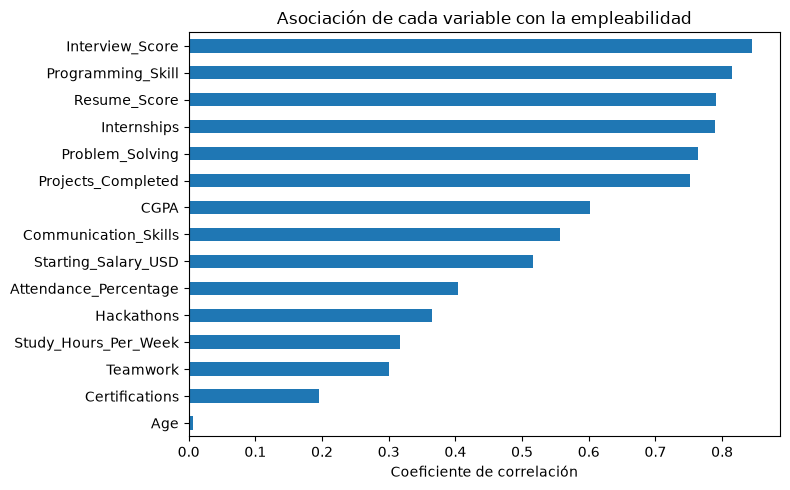

In [18]:
# Gráfica de barras con todas las correlaciones.
corr_todas.sort_values().plot.barh()
plt.title("Asociación de cada variable con la empleabilidad")
plt.xlabel("Coeficiente de correlación")
plt.tight_layout()
plt.show()

=== Correlación de las variables académicas con la empleabilidad ===
CGPA                        0.601
English_Proficiency_num     0.552
Academic_Performance_num    0.521
Attendance_Percentage       0.404
Study_Hours_Per_Week        0.317
Certifications              0.195
Name: Employability_Score, dtype: float64


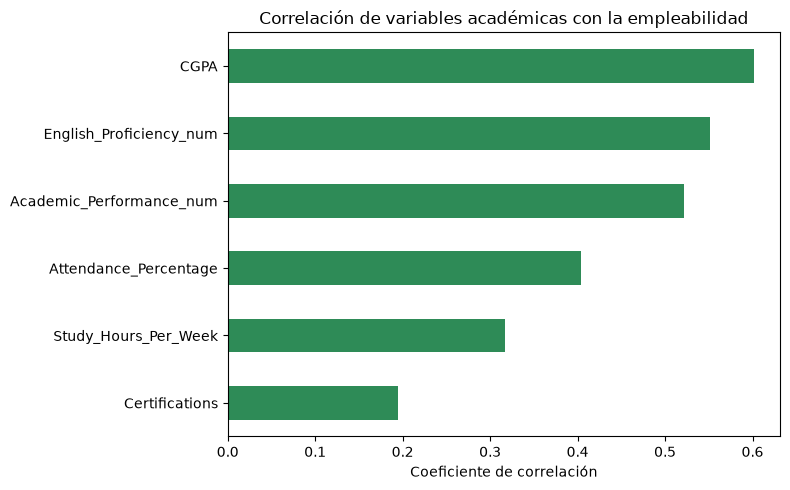

In [19]:
# Ahora SOLO las variables académicas.
# Dos de ellas son texto con orden → se convierten a número primero.
df["Academic_Performance_num"] = df["Academic_Performance"].map(
    {"Poor": 0, "Average": 1, "Good": 2, "Excellent": 3})
df["English_Proficiency_num"] = df["English_Proficiency"].map(
    {"Basic": 0, "Intermediate": 1, "Advanced": 2})

# Lista de variables académicas (las que describen el desempeño escolar del estudiante).
academicas = ["CGPA", "Academic_Performance_num", "English_Proficiency_num",
              "Attendance_Percentage", "Study_Hours_Per_Week", "Certifications"]

corr_academicas = (df[academicas + ["Employability_Score"]]
                   .corr()["Employability_Score"]
                   .drop("Employability_Score")
                   .sort_values(ascending=False))

print("=== Correlación de las variables académicas con la empleabilidad ===")
print(corr_academicas.round(3))

# Gráfica de las académicas.
corr_academicas.sort_values().plot.barh(color="seagreen")
plt.title("Correlación de variables académicas con la empleabilidad")
plt.xlabel("Coeficiente de correlación")
plt.tight_layout()
plt.show()

=== Correlación de todas las variables numéricas (con dispersión) ===
Interview_Score          0.845
Programming_Skill        0.814
Resume_Score             0.791
Internships              0.790
Problem_Solving          0.764
Projects_Completed       0.752
CGPA                     0.601
Communication_Skills     0.557
Attendance_Percentage    0.404
Hackathons               0.365
Study_Hours_Per_Week     0.317
Teamwork                 0.301
Certifications           0.195
Name: Employability_Score, dtype: float64


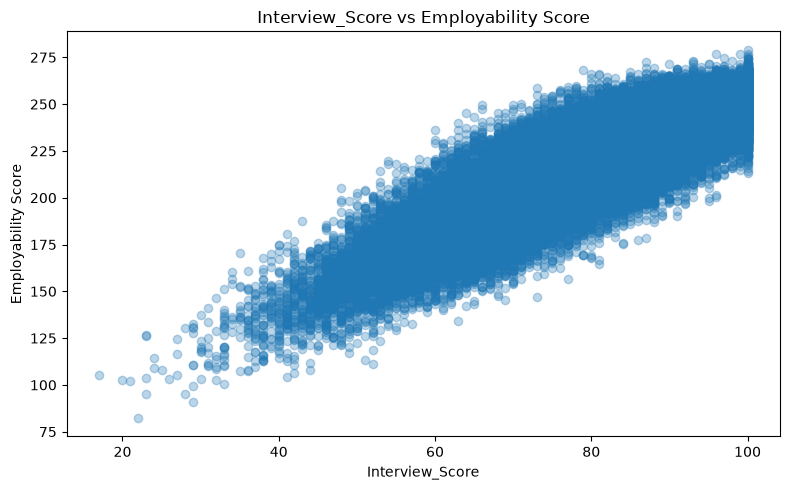

In [20]:
# Correlación también con la empleabilidad vista desde el análisis descriptivo anterior.
print("=== Correlación de todas las variables numéricas (con dispersión) ===")
print(corr_desc.round(3))

# Gráfica de relación entre la variable más importante y la empleabilidad.
plt.scatter(df[variable_mayor_relacion], df["Employability_Score"], alpha=0.3)
plt.title(f"{variable_mayor_relacion} vs Employability Score")
plt.xlabel(variable_mayor_relacion)
plt.ylabel("Employability Score")
plt.tight_layout()
plt.show()

**Respuesta (P1):** entre las variables **académicas**, la de mayor asociación con la empleabilidad es el **CGPA (promedio acumulado), con r = 0.60**, seguida del nivel de inglés (0.55) y el rendimiento académico (0.52).

Considerando todas las variables, la mayor es `Interview_Score` (r = 0.84), que corresponde al desempeño en la entrevista (no es académica). La **edad** es la de menor asociación (r = 0.007).

## 11. Pregunta 2 - ¿Qué habilidades blandas diferencian más a los contratados?

Se calcula la correlación de cada habilidad blanda con la contratación y se comparan los promedios entre contratados y no contratados. Incluimos `Leadership_Experience` convirtiéndola a número.

In [21]:
# Convertimos las columnas necesarias a valores numéricos.
# Placement_Status: 1 = contratado, 0 = no contratado.
# Leadership_Experience: 1 = Sí tiene, 0 = No tiene.
df["Placement_bin"]      = df["Placement_Status"].map({"Placed": 1, "Not Placed": 0})
df["Leadership_bin"]     = df["Leadership_Experience"].map({"Yes": 1, "No": 0})

# Habilidades blandas a evaluar (incluye liderazgo).
blandas = ["Communication_Skills", "Teamwork", "Problem_Solving", "Leadership_bin"]

# --- 1. Correlación de cada habilidad blanda con la contratación ---
corr_blandas = (df[blandas + ["Placement_bin"]]
                .corr()["Placement_bin"]
                .drop("Placement_bin")
                .sort_values(ascending=False))

print("=== Correlación con la contratación ===")
print(corr_blandas.round(3))

=== Correlación con la contratación ===
Problem_Solving         0.348
Communication_Skills    0.275
Teamwork                0.141
Leadership_bin          0.118
Name: Placement_bin, dtype: float64


In [22]:
# --- 2. Promedio de cada habilidad según si fue contratado o no ---
comparacion = df.groupby("Placement_Status")[blandas].mean().round(2)
print("=== Promedio por grupo (Placed vs Not Placed) ===")
print(comparacion)

# --- 3. Diferencia entre grupos ---
# La mayor diferencia indica la habilidad que más separa a los dos grupos.
diferencia = (comparacion.loc["Placed"] - comparacion.loc["Not Placed"]).sort_values(ascending=False)
print("\n=== Diferencia (contratados - no contratados) ===")
print(diferencia.round(2))

=== Promedio por grupo (Placed vs Not Placed) ===
                  Communication_Skills  Teamwork  Problem_Solving  \
Placement_Status                                                    
Not Placed                        7.72      6.58             6.07   
Placed                            8.64      7.13             7.48   

                  Leadership_bin  
Placement_Status                  
Not Placed                  0.28  
Placed                      0.42  

=== Diferencia (contratados - no contratados) ===
Problem_Solving         1.41
Communication_Skills    0.92
Teamwork                0.55
Leadership_bin          0.14
dtype: float64


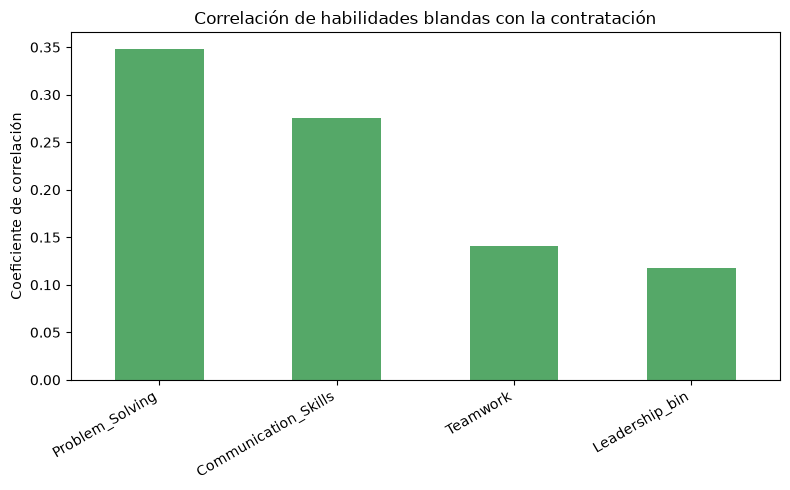

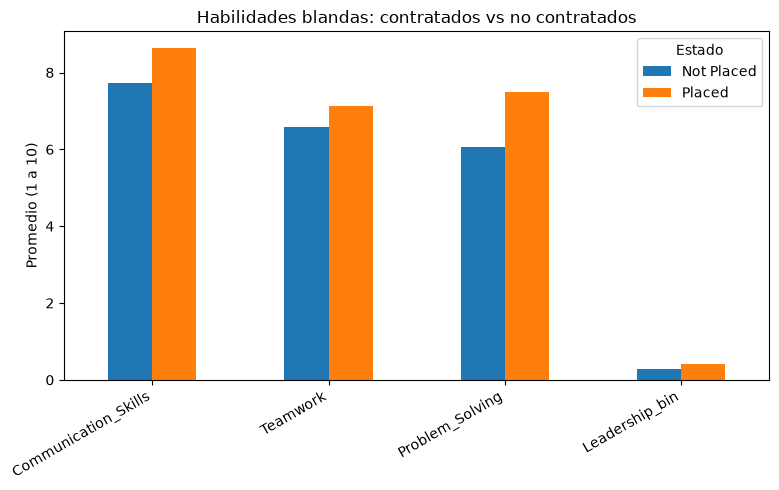


Conclusión: la habilidad blanda con mayor asociación con la contratación es 'Problem_Solving' (r = 0.348).


In [23]:
# --- 4. Gráfica de correlación de habilidades blandas con la contratación ---
corr_blandas.plot.bar(color="#55A868")
plt.title("Correlación de habilidades blandas con la contratación")
plt.ylabel("Coeficiente de correlación")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# --- 5. Gráfica comparativa de promedios por grupo ---
comparacion.T.plot.bar()
plt.title("Habilidades blandas: contratados vs no contratados")
plt.ylabel("Promedio (1 a 10)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Estado")
plt.tight_layout()
plt.show()

print(f"\nConclusión: la habilidad blanda con mayor asociación con la contratación es "
      f"'{corr_blandas.index[0]}' (r = {corr_blandas.iloc[0]:.3f}).")

**Respuesta (P2):** la habilidad blanda que más diferencia a los contratados es la **resolución de problemas** (`Problem_Solving`), tanto en correlación como en diferencia de promedios. El trabajo en equipo (`Teamwork`) es la que menos los distingue.

## 12. Pregunta 3 - ¿La empleabilidad y el salario varían según el género y la carrera?

In [24]:
# --- 1. Empleabilidad promedio por género (todos los estudiantes) ---
empl_genero = df.groupby("Gender")["Employability_Score"].mean().sort_values(ascending=False)
print("=== Empleabilidad promedio por género ===")
print(empl_genero.round(2))

# --- 2. Salario promedio por género (solo contratados, usando df_pagados) ---
# Usamos df_pagados para excluir los salarios en 0 de los no contratados.
sal_genero = df_pagados.groupby("Gender")["Starting_Salary_USD"].mean().sort_values(ascending=False)
print("\n=== Salario promedio por género ===")
print(sal_genero.round(2))

# --- 3. Empleabilidad promedio por carrera ---
empl_carrera = df.groupby("Major")["Employability_Score"].mean().sort_values(ascending=False)
print("\n=== Empleabilidad promedio por carrera ===")
print(empl_carrera.round(2))

# --- 4. Salario promedio por carrera (solo contratados) ---
sal_carrera = df_pagados.groupby("Major")["Starting_Salary_USD"].mean().sort_values(ascending=False)
print("\n=== Salario promedio por carrera ===")
print(sal_carrera.round(2))

=== Empleabilidad promedio por género ===
Gender
Male      214.03
Female    213.97
Other     213.58
Name: Employability_Score, dtype: float64

=== Salario promedio por género ===
Gender
Female    88464.12
Male      88282.43
Other     87523.68
Name: Starting_Salary_USD, dtype: float64

=== Empleabilidad promedio por carrera ===
Major
Artificial Intelligence    226.63
Software Engineering       226.06
Computer Science           215.12
Cybersecurity              215.12
Data Science               214.96
Information Technology     203.49
Business Analytics         189.87
Electrical Engineering     189.43
Name: Employability_Score, dtype: float64

=== Salario promedio por carrera ===
Major
Artificial Intelligence    89531.40
Software Engineering       89347.29
Cybersecurity              88898.82
Data Science               88873.39
Computer Science           88702.61
Information Technology     87318.08
Business Analytics         83870.11
Electrical Engineering     83215.52
Name: Starting_Sala

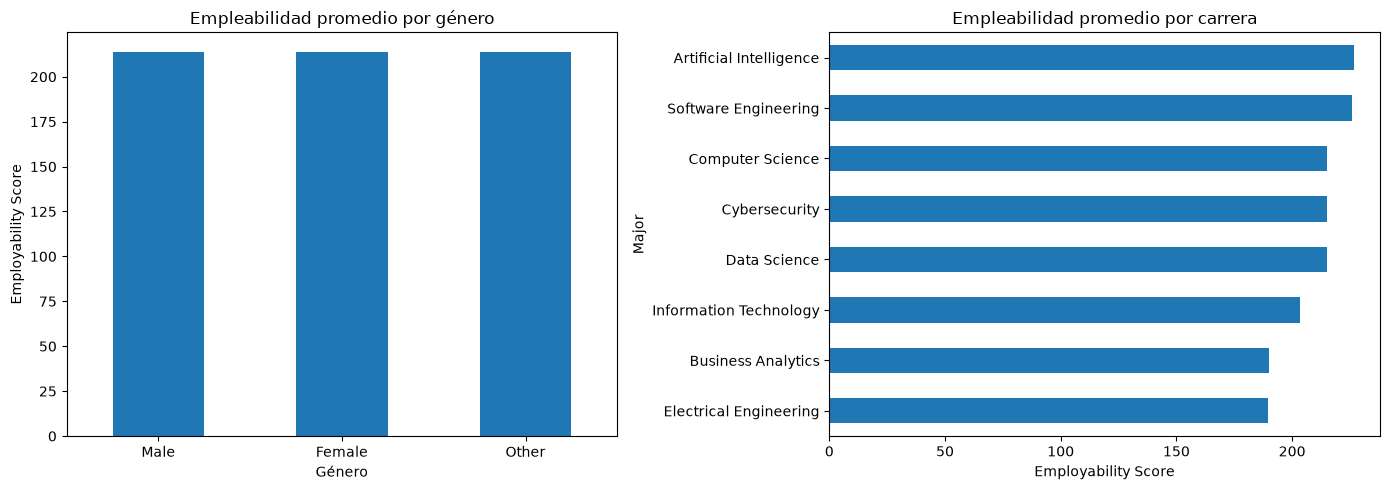

In [25]:
# --- 5. Gráfica de empleabilidad por género ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

empl_genero.plot.bar(ax=axes[0])
axes[0].set_title("Empleabilidad promedio por género")
axes[0].set_xlabel("Género")
axes[0].set_ylabel("Employability Score")
axes[0].tick_params(axis="x", rotation=0)

# --- 6. Gráfica de empleabilidad por carrera ---
empl_carrera.sort_values().plot.barh(ax=axes[1])
axes[1].set_title("Empleabilidad promedio por carrera")
axes[1].set_xlabel("Employability Score")

plt.tight_layout()
plt.show()

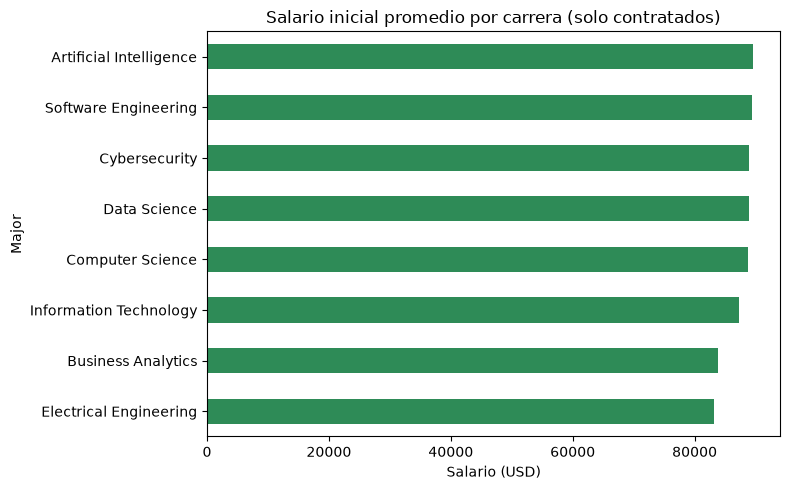

=== Conclusiones ===
Mayor empleabilidad por género: 'Male'.
Mayor empleabilidad por carrera: 'Artificial Intelligence'.
Mayor salario por género: 'Female'.
Mayor salario por carrera: 'Artificial Intelligence'.


In [26]:
# --- 7. Gráfica de salario por carrera ---
sal_carrera.sort_values().plot.barh(color="seagreen")
plt.title("Salario inicial promedio por carrera (solo contratados)")
plt.xlabel("Salario (USD)")
plt.tight_layout()
plt.show()

# --- 8. Conclusiones automáticas ---
print("=== Conclusiones ===")
print(f"Mayor empleabilidad por género: '{empl_genero.index[0]}'.")
print(f"Mayor empleabilidad por carrera: '{empl_carrera.index[0]}'.")
print(f"Mayor salario por género: '{sal_genero.index[0]}'.")
print(f"Mayor salario por carrera: '{sal_carrera.index[0]}'.")

**Respuesta (P3):** tanto la empleabilidad como el salario son prácticamente iguales entre géneros (sin brecha relevante). Por carrera sí hay variación moderada: **Inteligencia Artificial y Software Engineering** presentan los valores más altos y **Business Analytics y Electrical Engineering** los más bajos.

## 13. Pregunta 4 — ¿Qué diferencia hay entre estudiantes con y sin experiencia previa?

Se analiza tanto el salario como la **tasa de contratación** según si el estudiante realizó prácticas o no.

In [27]:
# --- 1. Crear variable de experiencia previa ---
# Un estudiante tiene experiencia si realizó al menos 1 práctica (Internships > 0).
df["Experiencia_Previa"] = df["Internships"].apply(
    lambda x: "Con experiencia" if x > 0 else "Sin experiencia")

# --- 2. Cuántos estudiantes hay en cada grupo ---
print("=== Cantidad de estudiantes por grupo ===")
print(df["Experiencia_Previa"].value_counts())

=== Cantidad de estudiantes por grupo ===
Experiencia_Previa
Con experiencia    49940
Sin experiencia       59
Name: count, dtype: int64


In [28]:
# --- 3. Salario promedio por grupo (solo contratados) ---
sal_exp = (df_pagados
           .assign(Experiencia_Previa=df_pagados["Internships"].apply(
               lambda x: "Con experiencia" if x > 0 else "Sin experiencia"))
           .groupby("Experiencia_Previa")["Starting_Salary_USD"]
           .agg(["count", "mean"])
           .round(0))

print("=== Salario y cantidad de contratados por grupo ===")
print(sal_exp)

# --- 4. Diferencia de salario ---
sal_con = sal_exp.loc["Con experiencia", "mean"]
sal_sin = sal_exp.loc["Sin experiencia", "mean"]
diferencia_sal = sal_con - sal_sin
pct_diferencia = (diferencia_sal / sal_sin) * 100

print(f"\n=== Diferencia salarial ===")
print(f"{diferencia_sal:.2f} USD")
print(f"\n=== Diferencia porcentual ===")
print(f"{pct_diferencia:.2f}%")

# --- 5. Conclusión automática sobre salario ---
print(f"\nConclusión: los estudiantes con experiencia tienen un salario promedio "
      f"superior en {diferencia_sal:.2f} USD ({pct_diferencia:.2f}%) frente a los sin experiencia.")

=== Salario y cantidad de contratados por grupo ===
                    count     mean
Experiencia_Previa                
Con experiencia     39035  88361.0
Sin experiencia         4  37983.0

=== Diferencia salarial ===
50378.00 USD

=== Diferencia porcentual ===
132.63%

Conclusión: los estudiantes con experiencia tienen un salario promedio superior en 50378.00 USD (132.63%) frente a los sin experiencia.


=== Tasa de contratación por grupo (%) ===
Experiencia_Previa
Con experiencia    78.2
Sin experiencia     6.8
Name: Placement_Status, dtype: float64


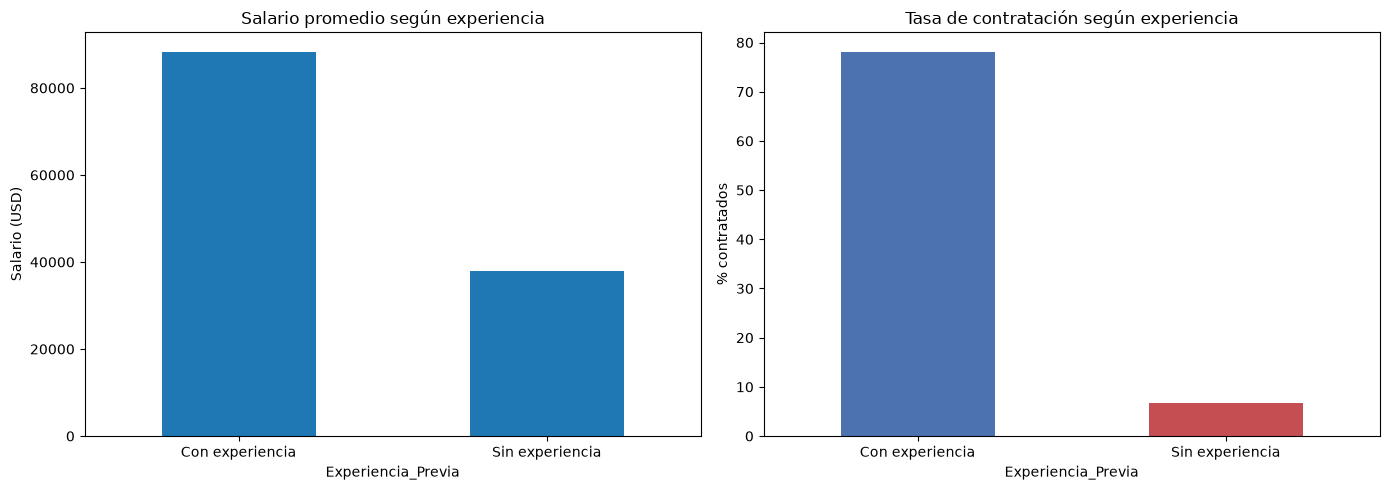

In [29]:
# --- 6. Tasa de contratación por grupo ---
# ¿Qué porcentaje de cada grupo consiguió empleo?
# Este es el indicador más sólido para esta pregunta.
tasa = df.groupby("Experiencia_Previa")["Placement_Status"].apply(
    lambda s: (s == "Placed").mean()) * 100

print("=== Tasa de contratación por grupo (%) ===")
print(tasa.round(1))

# --- 7. Gráficas ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de salario
sal_exp["mean"].plot.bar(ax=axes[0])
axes[0].set_title("Salario promedio según experiencia")
axes[0].set_ylabel("Salario (USD)")
axes[0].tick_params(axis="x", rotation=0)

# Gráfica de tasa de contratación
tasa.plot.bar(ax=axes[1], color=["#4C72B0", "#C44E52"])
axes[1].set_title("Tasa de contratación según experiencia")
axes[1].set_ylabel("% contratados")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

**Respuesta (P4):** la experiencia previa tiene un efecto muy grande: la tasa de contratación es ~**78%** con prácticas frente a ~**7%** sin ellas.

**Nota importante sobre el salario:** aunque la diferencia de salario entre grupos es grande (~50.000 USD), el grupo "Sin experiencia" contratado es de muy pocos estudiantes, por lo que ese promedio no es estadísticamente representativo. La **tasa de contratación** es el indicador más adecuado para esta pregunta.

## 14. Pregunta 5 - ¿Qué variables se asocian más con el tipo de empresa?

Entre los estudiantes contratados, analizamos qué variables se relacionan más con conseguir una empresa de **Tier 1** (el nivel más alto).

In [30]:
# Solo estudiantes contratados (para analizar el tipo de empresa, necesitan haber sido colocados).
df_colocados = df[df["Placement_Status"] == "Placed"].copy()

# Variable binaria: 1 si consiguió Tier 1, 0 si consiguió Tier 2 o Tier 3.
df_colocados["Es_Tier1"] = df_colocados["Company_Tier"].apply(
    lambda x: 1 if x == "Tier 1" else 0)

# Variables a evaluar para predecir el Tier.
vars_tier = [
    "CGPA", "Attendance_Percentage", "Study_Hours_Per_Week",
    "Communication_Skills", "Teamwork", "Problem_Solving",
    "Programming_Skill", "Projects_Completed", "Internships",
    "Resume_Score", "Interview_Score"
]

# --- 1. Correlación de cada variable con conseguir Tier 1 ---
corr_tier = (df_colocados[vars_tier + ["Es_Tier1"]]
             .corr()["Es_Tier1"]
             .drop("Es_Tier1")
             .sort_values(ascending=False))

print("=== Correlación con conseguir empresa Tier 1 ===")
print(corr_tier.round(3))

=== Correlación con conseguir empresa Tier 1 ===
Resume_Score             0.661
Interview_Score          0.434
Internships              0.432
Programming_Skill        0.377
Problem_Solving          0.344
Projects_Completed       0.341
Communication_Skills     0.272
CGPA                     0.247
Attendance_Percentage    0.174
Teamwork                 0.133
Study_Hours_Per_Week     0.114
Name: Es_Tier1, dtype: float64


In [31]:
# --- 2. Comparación de promedios: Tier 1 vs Tier 2 o Tier 3 ---
df_colocados["Grupo_Tier"] = df_colocados["Company_Tier"].apply(
    lambda x: "Tier 1" if x == "Tier 1" else "Tier 2 o 3")

comparacion_tier = df_colocados.groupby("Grupo_Tier")[vars_tier].mean().round(2)
print("=== Promedio por nivel de empresa ===")
print(comparacion_tier)

# --- 3. Diferencia entre los dos grupos ---
diferencia_tier = (comparacion_tier.loc["Tier 1"] - comparacion_tier.loc["Tier 2 o 3"]).round(2)
print("\n=== Diferencia (Tier 1 - Tier 2/3) ===")
print(diferencia_tier.sort_values(ascending=False))

=== Promedio por nivel de empresa ===
            CGPA  Attendance_Percentage  Study_Hours_Per_Week  \
Grupo_Tier                                                      
Tier 1      3.16                  82.73                 22.23   
Tier 2 o 3  2.84                  75.06                 18.53   

            Communication_Skills  Teamwork  Problem_Solving  \
Grupo_Tier                                                    
Tier 1                      8.72      7.17             7.60   
Tier 2 o 3                  7.08      6.18             5.12   

            Programming_Skill  Projects_Completed  Internships  Resume_Score  \
Grupo_Tier                                                                     
Tier 1                   7.55                9.26         4.34         98.47   
Tier 2 o 3               5.13                5.56         2.59         82.50   

            Interview_Score  
Grupo_Tier                   
Tier 1                81.28  
Tier 2 o 3            58.82  

=== Di

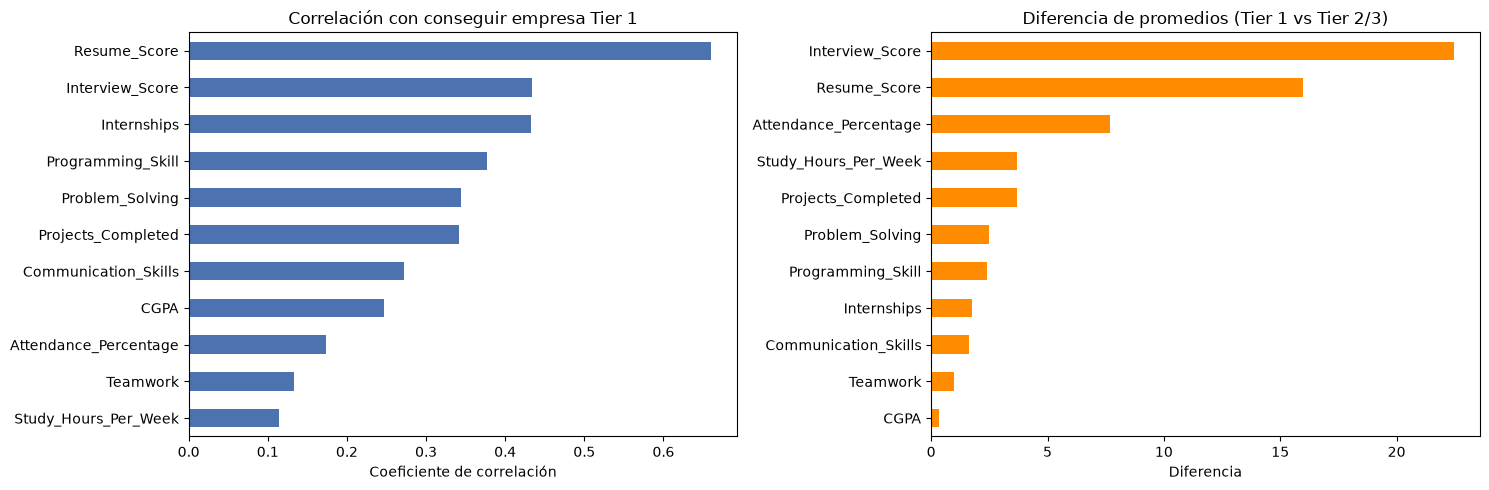


Conclusión: la variable más asociada con conseguir Tier 1 es 'Resume_Score' (r = 0.661), seguida de 'Interview_Score' (0.434).


In [32]:
# --- 4. Gráficas ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

corr_tier.sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("Correlación con conseguir empresa Tier 1")
axes[0].set_xlabel("Coeficiente de correlación")

diferencia_tier.sort_values().plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("Diferencia de promedios (Tier 1 vs Tier 2/3)")
axes[1].set_xlabel("Diferencia")

plt.tight_layout()
plt.show()

print(f"\nConclusión: la variable más asociada con conseguir Tier 1 es "
      f"'{corr_tier.index[0]}' (r = {corr_tier.iloc[0]:.3f}), "
      f"seguida de '{corr_tier.index[1]}' ({corr_tier.iloc[1]:.3f}).")

**Respuesta (P5):** la variable más asociada con conseguir empresa Tier 1 es el **puntaje de la hoja de vida** (`Resume_Score`, r = 0.66), seguida del puntaje de entrevista (0.43) y el número de prácticas (0.43).

## 15. Pregunta principal - Modelo predictivo

Para determinar qué factores **predicen** la empleabilidad entrenamos un modelo de clasificación (Random Forest). El modelo aprende de los datos y estima cuánto pesa cada variable.

Se excluyen las **variables de resultado** (salario, nivel de empresa, campo, modo de contratación y el puntaje de empleabilidad), ya que solo existen después de la contratación y darían información que revela la respuesta (esto se llama *fuga de datos*).

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- Preparar las variables para el modelo ---
# Los modelos solo entienden números; convertimos texto a número.
datos = df.copy()

# Variables con orden natural → número que respeta ese orden.
datos["Academic_Performance"] = datos["Academic_Performance"].map(
    {"Poor":0,"Average":1,"Good":2,"Excellent":3})
datos["English_Proficiency"]  = datos["English_Proficiency"].map(
    {"Basic":0,"Intermediate":1,"Advanced":2})
datos["University_Year"]      = datos["University_Year"].map(
    {"Freshman":0,"Sophomore":1,"Junior":2,"Senior":3})

# Variables Sí/No → 1/0.
for col in ["GitHub_Profile","LinkedIn_Profile","Leadership_Experience"]:
    datos[col] = datos[col].map({"No":0,"Yes":1})

# Columnas que son resultado (solo existen después de la contratación) → se excluyen.
excluir = ["Employability_Score","Placement_Status","Company_Tier","Career_Field",
           "Placement_Mode","Starting_Salary_USD","Student_ID",
           "Academic_Performance_num","English_Proficiency_num",
           "Placement_bin","Leadership_bin","Experiencia_Previa",
           "Grupo_Tier","Es_Tier1"]

X = datos.drop(columns=[c for c in excluir if c in datos.columns])

# Género y carrera (sin orden) → columnas 0/1 (una por categoría).
X = pd.get_dummies(X, columns=["Gender","Major"], drop_first=True)
print("Variables predictoras usadas:", X.shape[1])

Variables predictoras usadas: 29


In [34]:
# Variable objetivo: 1 si el estudiante fue contratado, 0 si no.
y = (df["Placement_Status"] == "Placed").astype(int)

# Dividimos los datos: 80% para entrenar el modelo, 20% para evaluarlo.
# El modelo nunca ve el 20% de prueba durante el entrenamiento.
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Entrenamos el modelo Random Forest (combina 200 árboles de decisión).
modelo = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
modelo.fit(X_tr, y_tr)

# Evaluamos la precisión: porcentaje de aciertos sobre los datos de prueba.
predicciones = modelo.predict(X_te)
print("Precisión del modelo:", round(accuracy_score(y_te, predicciones), 3))

print("\nReporte detallado:")
print(classification_report(y_te, predicciones, target_names=["No contratado","Contratado"]))

Precisión del modelo: 0.815

Reporte detallado:
               precision    recall  f1-score   support

No contratado       0.64      0.36      0.46      2192
   Contratado       0.84      0.94      0.89      7808

     accuracy                           0.81     10000
    macro avg       0.74      0.65      0.67     10000
 weighted avg       0.80      0.81      0.79     10000



Variables más importantes para predecir la contratación:
Interview_Score          0.105
Resume_Score             0.097
CGPA                     0.084
Attendance_Percentage    0.070
Study_Hours_Per_Week     0.066
Projects_Completed       0.057
Programming_Skill        0.057
Problem_Solving          0.049
Internships              0.048
Age                      0.046
dtype: float64


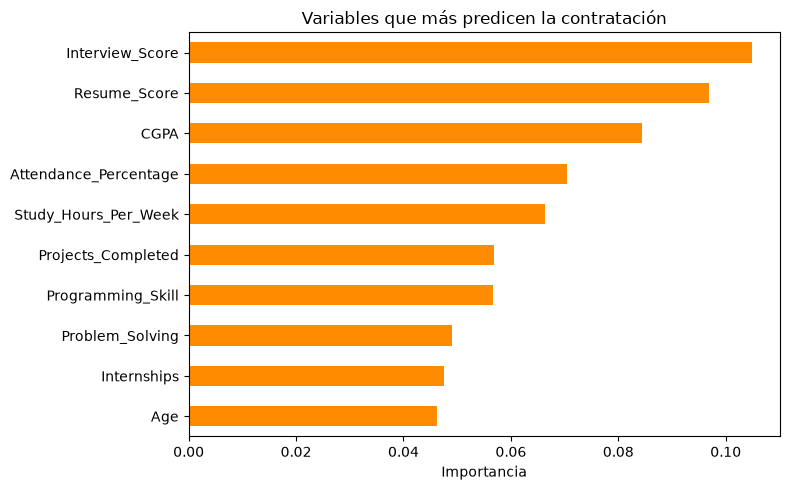

In [35]:
# Variables que más pesaron en la predicción (importancia de cada una).
importancia = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Variables más importantes para predecir la contratación:")
print(importancia.head(10).round(3))

# Gráfica de las 10 variables más importantes.
importancia.head(10).sort_values().plot.barh(color="darkorange")
plt.title("Variables que más predicen la contratación")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

Precisión prediciendo el nivel de empresa: 0.988

Variables más importantes para el nivel de empresa:
Resume_Score           0.230
Interview_Score        0.178
Programming_Skill      0.096
Internships            0.091
Problem_Solving        0.062
CGPA                   0.059
Projects_Completed     0.057
English_Proficiency    0.030
dtype: float64


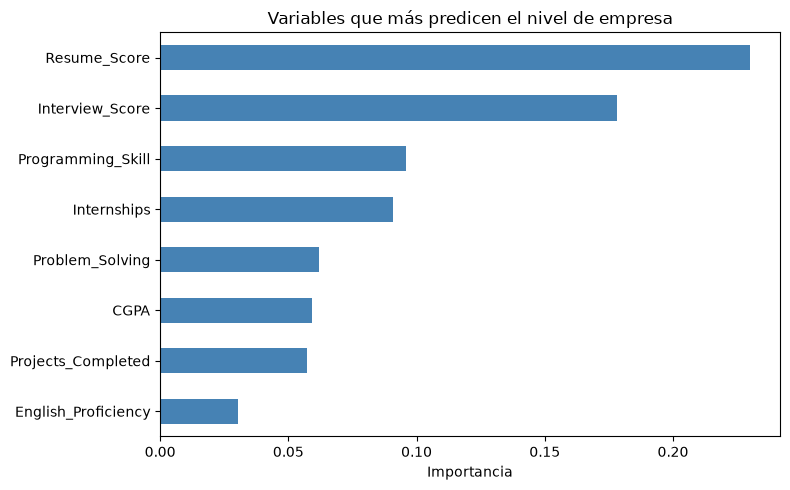

In [36]:
# --- MODELO 2: predecir el nivel de empresa (Tier) entre los contratados ---
# Solo usamos los estudiantes que sí fueron contratados.
contratados_idx = df["Placement_Status"] == "Placed"
Xc = X[contratados_idx]
yc = df.loc[contratados_idx, "Company_Tier"]

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)

modelo_tier = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
modelo_tier.fit(Xc_tr, yc_tr)
print("Precisión prediciendo el nivel de empresa:", round(accuracy_score(yc_te, modelo_tier.predict(Xc_te)), 3))

# Variables más importantes para predecir el Tier.
imp_tier = pd.Series(modelo_tier.feature_importances_, index=Xc.columns).sort_values(ascending=False)
print("\nVariables más importantes para el nivel de empresa:")
print(imp_tier.head(8).round(3))

imp_tier.head(8).sort_values().plot.barh(color="steelblue")
plt.title("Variables que más predicen el nivel de empresa")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

**Respuesta (pregunta principal):** el modelo alcanza una precisión de ~**81%**. La empleabilidad se predice mejor mediante la combinación de: **puntaje de entrevista, puntaje de la hoja de vida, CGPA, asistencia y proyectos completados**.

El modelo de nivel de empresa alcanza ~**99%** de precisión: las mismas variables de desempeño que predicen la contratación también determinan en qué nivel de empresa queda el estudiante.

## 16. Conclusiones

| Pregunta | Respuesta |
|---|---|
| **P1 — Variable académica** | CGPA (r = 0.60) es la académica más asociada. Considerando todas las variables, `Interview_Score` lidera (r = 0.84). |
| **P2 — Habilidad blanda** | Resolución de problemas (`Problem_Solving`) es la que más diferencia a los contratados. |
| **P3 — Género y carrera** | Sin brecha por género. Por carrera: IA y Software Engineering tienen mayores empleabilidad y salario. |
| **P4 — Experiencia previa** | Tasa de contratación: ~78% con prácticas vs ~7% sin ellas. |
| **P5 — Tipo de empresa** | `Resume_Score` (r = 0.66) e `Interview_Score` (r = 0.43) son las más asociadas con conseguir Tier 1. |
| **Principal — Modelo** | Predice la contratación con ~81% de acierto. Las variables más importantes: entrevista, hoja de vida, CGPA, asistencia y proyectos. |

## 17. Limitaciones

- **Correlación no implica causalidad:** una asociación alta entre dos variables no significa que una cause a la otra.
- **Pregunta 4 — muestra pequeña:** el grupo de contratados sin prácticas es muy pequeño (pocos estudiantes), por lo que el promedio de salario de ese grupo no es estadísticamente representativo. La tasa de contratación es el indicador más sólido.
- **Posible dato sintético:** el conjunto de datos presenta correlaciones muy regulares, lo que sugiere que podría haber sido generado artificialmente. Los resultados deben interpretarse como una demostración de la metodología, no como conclusiones generalizables a población real.